## ML TA 2
### Name: Shantanu Ingle
### Roll no. 57
### Sec : A

Credit Card Customer Segmentation

Dataset: Credit Card Dataset

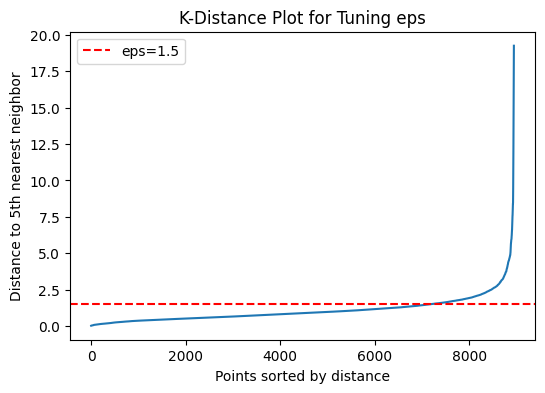

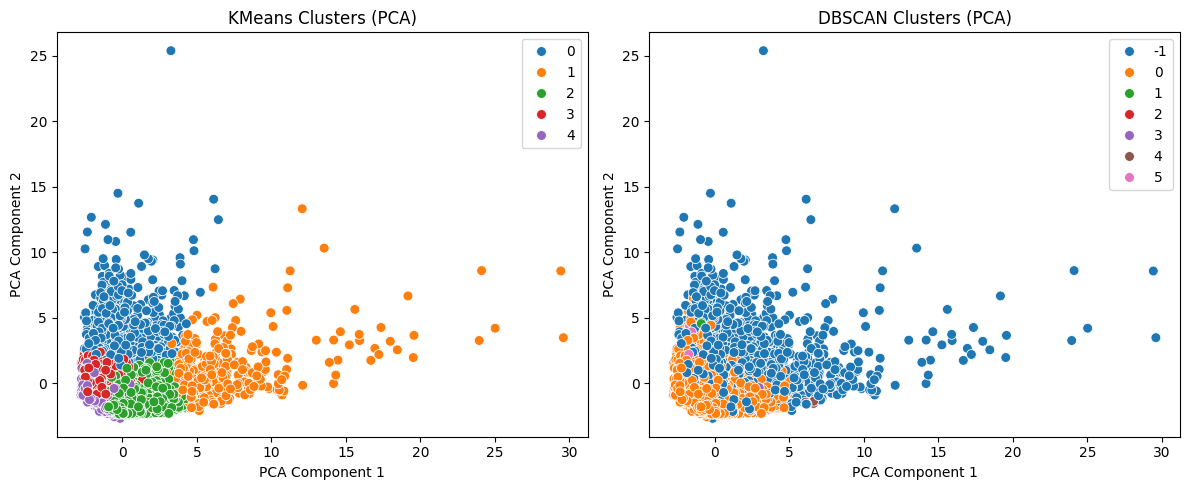

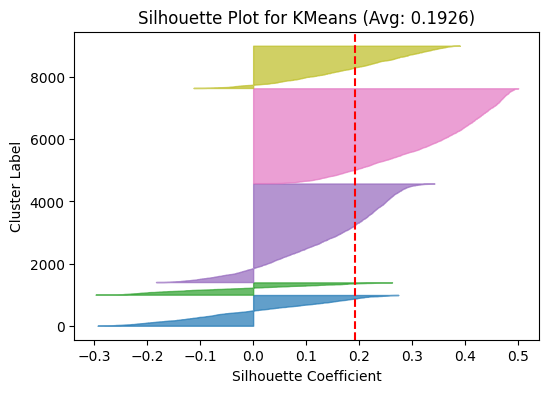

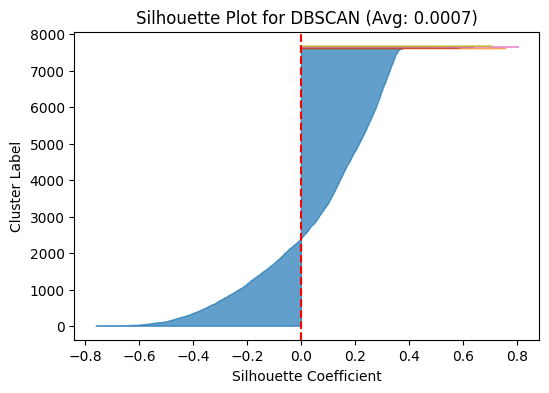


Clustering Performance Comparison:
Algorithm  Silhouette Score  Calinski-Harabasz Index  Davies-Bouldin Index
   KMeans          0.192566              1456.792713              1.468162
   DBSCAN          0.000704               174.786712              1.951590

DBSCAN Results: 6 clusters, 1320 noise points


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
from sklearn.neighbors import NearestNeighbors
import warnings
import os


os.environ["JOBLIB_MULTIPROCESSING"] = "0"

warnings.filterwarnings(action="ignore")

# Load the dataset
file_path = 'CC GENERAL.csv'
customer = pd.read_csv(file_path)

# Preprocessing
X = customer.drop('CUST_ID', axis=1)
X['CREDIT_LIMIT'] = X['CREDIT_LIMIT'].fillna(X['CREDIT_LIMIT'].median())
X['MINIMUM_PAYMENTS'] = X['MINIMUM_PAYMENTS'].fillna(X['MINIMUM_PAYMENTS'].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Tune DBSCAN eps using k-distance plot ---
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(6, 4))
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th nearest neighbor")
plt.title("K-Distance Plot for Tuning eps")
plt.axhline(y=1.5, color='r', linestyle='--', label='eps=1.5')
plt.legend()
plt.show()

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Apply DBSCAN clustering with adjusted eps
dbscan = DBSCAN(eps=1.5, min_samples=5) 
dbscan_labels = dbscan.fit_predict(X_scaled)

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Scatterplot for KMeans and DBSCAN ---
plt.figure(figsize=(12, 5))

# KMeans Scatterplot
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='tab10', s=50)
plt.title('KMeans Clusters (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# DBSCAN Scatterplot
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='tab10', s=50)
plt.title('DBSCAN Clusters (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

# --- Silhouette Plot for KMeans and DBSCAN ---
def plot_silhouette(X, labels, title, n_clusters):
    plt.figure(figsize=(6, 4))
    silhouette_avg = silhouette_score(X, labels) if n_clusters >= 2 else -1
    sample_silhouette_values = silhouette_samples(X, labels)
    
    y_lower = 10
    for i in range(n_clusters):
        cluster_silhouette_values = sample_silhouette_values[labels == i]
        cluster_silhouette_values.sort()
        size_cluster_i = cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.tab10(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper + 10
    
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.title(f'Silhouette Plot for {title} (Avg: {silhouette_avg:.4f})')
    plt.xlabel('Silhouette Coefficient')
    plt.ylabel('Cluster Label')
    plt.show()

# KMeans Silhouette Plot
n_clusters_kmeans = len(set(kmeans_labels))
plot_silhouette(X_scaled, kmeans_labels, 'KMeans', n_clusters_kmeans)

# DBSCAN Silhouette Plot
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)
if n_clusters_dbscan >= 2:
    plot_silhouette(X_scaled, dbscan_labels, 'DBSCAN', n_clusters_dbscan)
else:
    print("DBSCAN Silhouette Plot skipped: fewer than 2 clusters found.")

# --- Clustering Performance Metrics ---
metrics = {'Algorithm': [], 'Silhouette Score': [], 'Calinski-Harabasz Index': [], 'Davies-Bouldin Index': []}

# KMeans Metrics
metrics['Algorithm'].append('KMeans')
metrics['Silhouette Score'].append(silhouette_score(X_scaled, kmeans_labels))
metrics['Calinski-Harabasz Index'].append(calinski_harabasz_score(X_scaled, kmeans_labels))
metrics['Davies-Bouldin Index'].append(davies_bouldin_score(X_scaled, kmeans_labels))

# DBSCAN Metrics
metrics['Algorithm'].append('DBSCAN')
if n_clusters_dbscan >= 2:
    metrics['Silhouette Score'].append(silhouette_score(X_scaled, dbscan_labels))
    metrics['Calinski-Harabasz Index'].append(calinski_harabasz_score(X_scaled, dbscan_labels))
    metrics['Davies-Bouldin Index'].append(davies_bouldin_score(X_scaled, dbscan_labels))
else:
    metrics['Silhouette Score'].append(np.nan)
    metrics['Calinski-Harabasz Index'].append(np.nan)
    metrics['Davies-Bouldin Index'].append(np.nan)
    print("DBSCAN metrics not computed: fewer than 2 clusters found.")

# Create comparison table
metrics_df = pd.DataFrame(metrics)
print("\nClustering Performance Comparison:")
print(metrics_df.to_string(index=False))

# Print DBSCAN-specific info
print(f"\nDBSCAN Results: {n_clusters_dbscan} clusters, {n_noise_dbscan} noise points")

KMeans outperforms DBSCAN in clustering the `customers.csv` dataset, with a better Silhouette Score (0.1926 vs. 0.0007), Calinski-Harabasz Index (1456.79 vs. 174.79), and Davies-Bouldin Index (1.4682 vs. 1.9516). DBSCAN identifies 6 clusters but marks 1320 points as noise, suggesting KMeans is more effective for this segmentation task, while DBSCAN may need tuning for better results.

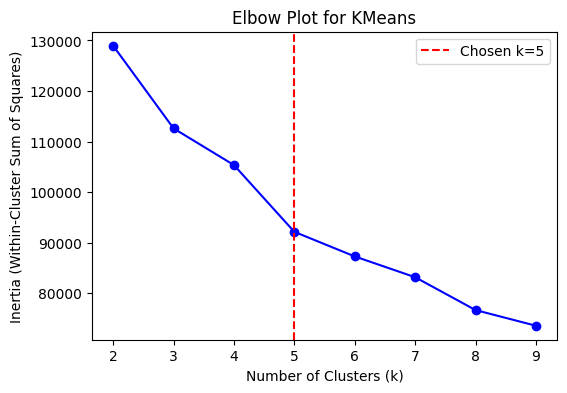

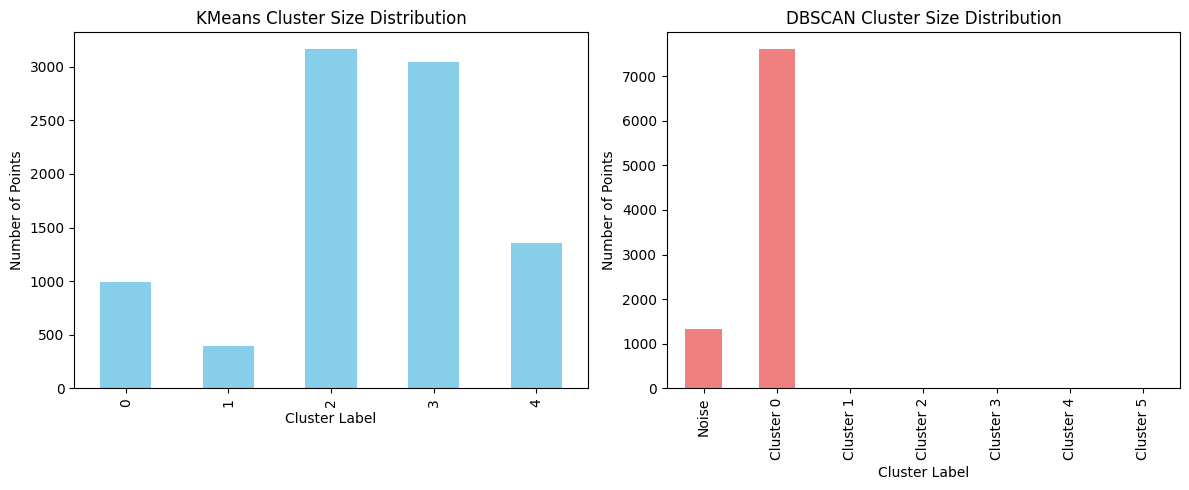

<Figure size 800x800 with 0 Axes>

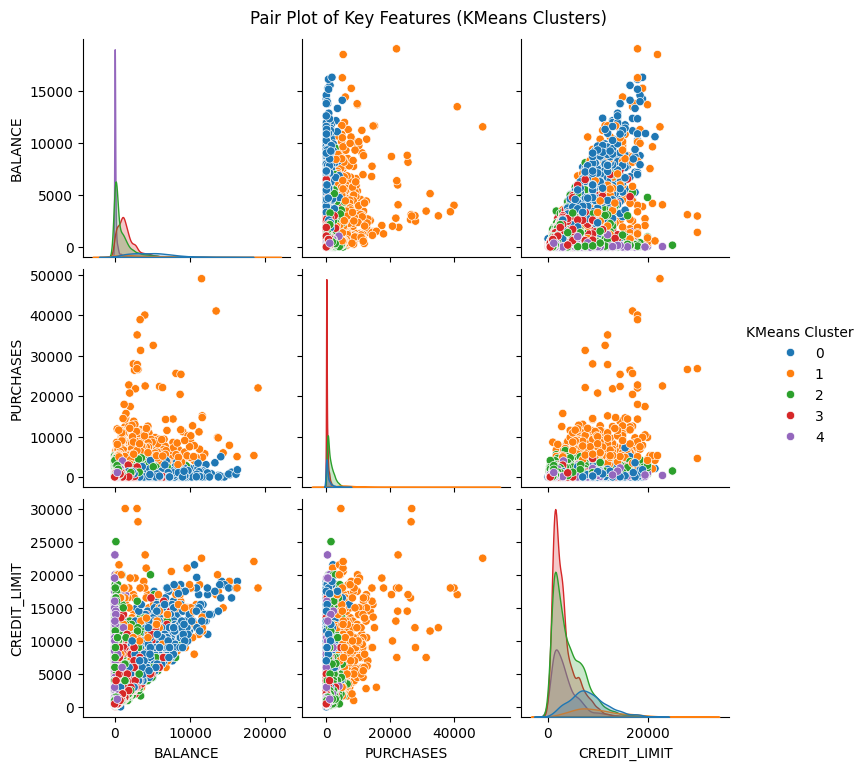

<Figure size 800x800 with 0 Axes>

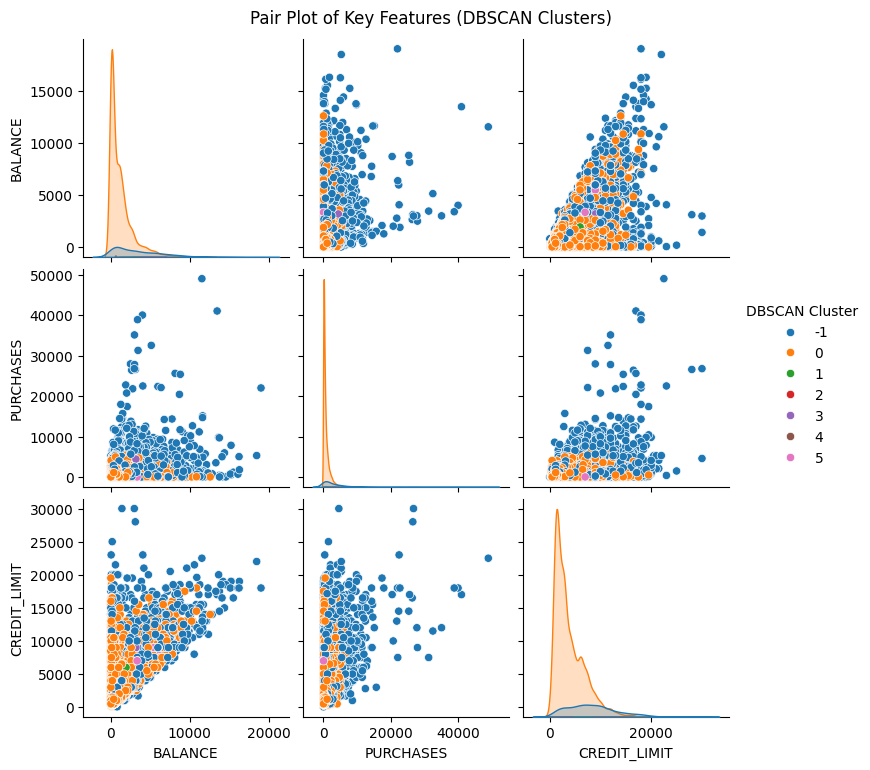

In [5]:
# Import necessary libraries (already imported in previous code, repeated for clarity)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# --- 1. Elbow Plot for KMeans ---
# Compute inertia (within-cluster sum of squares) for different numbers of clusters
inertias = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Plot for KMeans')
plt.axvline(x=5, color='r', linestyle='--', label='Chosen k=5')
plt.legend()
plt.show()

# --- 2. Cluster Size Distribution (Bar Plot) ---
# Compute cluster sizes for KMeans
kmeans_cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()

# Compute cluster sizes for DBSCAN (including noise as a separate "cluster")
dbscan_cluster_sizes = pd.Series(dbscan_labels).value_counts().sort_index()
# Rename the noise label (-1) for clarity in the plot
dbscan_cluster_sizes.index = dbscan_cluster_sizes.index.map(lambda x: 'Noise' if x == -1 else f'Cluster {x}')

# Plot cluster size distributions side by side
plt.figure(figsize=(12, 5))

# KMeans
plt.subplot(1, 2, 1)
kmeans_cluster_sizes.plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Points')
plt.title('KMeans Cluster Size Distribution')

# DBSCAN
plt.subplot(1, 2, 2)
dbscan_cluster_sizes.plot(kind='bar', color='lightcoral')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Points')
plt.title('DBSCAN Cluster Size Distribution')

plt.tight_layout()
plt.show()

# --- 3. Pair Plot of Key Features ---
# Select a few key features for visualization
key_features = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']
X_subset = X[key_features].copy()

# Add cluster labels to the dataframe
X_subset['KMeans Cluster'] = kmeans_labels
X_subset['DBSCAN Cluster'] = dbscan_labels

# Pair plot for KMeans
plt.figure(figsize=(8, 8))
sns.pairplot(X_subset, hue='KMeans Cluster', vars=key_features, palette='tab10', diag_kind='kde')
plt.suptitle('Pair Plot of Key Features (KMeans Clusters)', y=1.02)
plt.show()

# Pair plot for DBSCAN
plt.figure(figsize=(8, 8))
sns.pairplot(X_subset, hue='DBSCAN Cluster', vars=key_features, palette='tab10', diag_kind='kde')
plt.suptitle('Pair Plot of Key Features (DBSCAN Clusters)', y=1.02)
plt.show()